Lab-8: Bit Plane Slicing and Image Reconstruction

In [1]:
import PIL.Image as image 
import numpy as np 
import matplotlib.pyplot as plt 

a)	Read a grayscale image.

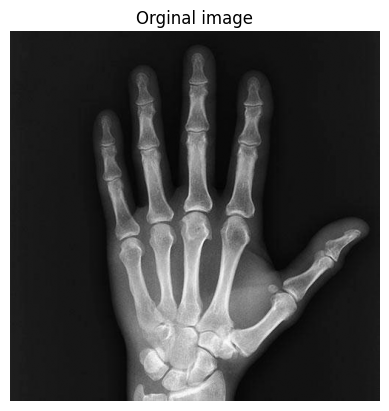

In [12]:
img = image.open("Images/hand_xray.jpg").convert("L")
img_array = np.array(img)
plt.subplot(1, 1, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Orginal image")
plt.axis("off")
plt.show()

b)	Apply bit plane slicing to extract all 8 bit planes (0–7) using the expression:
bit_plane_k = (img ≫ k)  & 1

c)	Store all the bit planes into an array.


In [13]:
bit_planes = []

for k in range(8):
    planes = (img_array >> k) & 1
    bit_planes.append(planes)

d)	Display all extracted bit planes in a 2 × 4 grid with appropriate titles (Bit Plane 0 to Bit Plane 7).

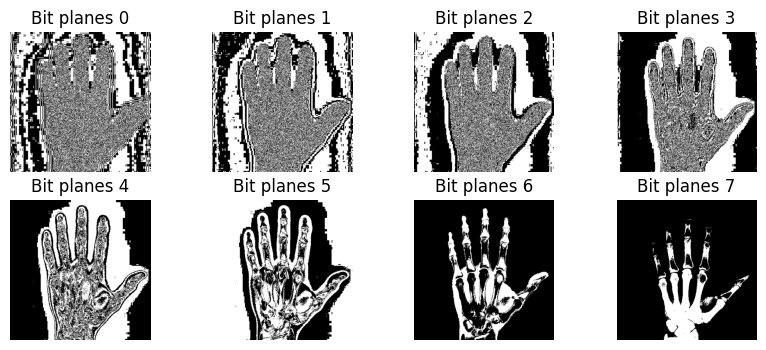

In [15]:
plt.figure(figsize=(10, 4))

for k in range(8):
    plt.subplot(2, 4, (k + 1))
    plt.imshow(bit_planes[k], cmap="gray")
    plt.title(f"Bit planes {k}")
    plt.axis("off")

plt.show()

e)	Reconstruct a new image using only the higher-order bit planes (bit planes 4–7) using the formula:
s = ∑(k=4)^7 bit_plan_k * 2^k


In [16]:
reconstructed = np.zeros_like(img_array)

for k in range(4, 8):
    reconstructed = reconstructed + bit_planes[k] * (2**k)

f)	Display both the original image and the reconstructed image with appropriate titles.

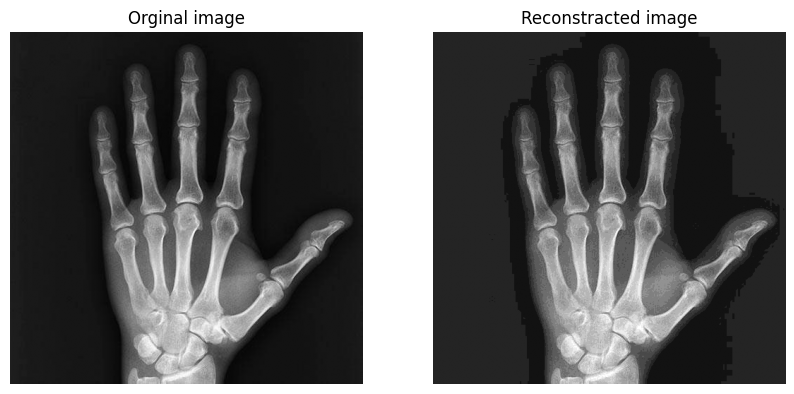

In [17]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Orginal image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstracted image")
plt.axis("off")

plt.show()